# XGBoost — Classificação da Qualidade de Vinhos

**Tech Challenge Fase 2 | POSTECH**  
**Responsável:** Vinicius Lopes

In [1]:
import pandas as pd

## 📂 Carregando a Base de Dados

A base utilizada é o resultado do pré-processamento realizado na etapa de EDA — 
com duplicatas removidas, coluna `Id` excluída e variável alvo binária já criada.

In [2]:
df = pd.read_csv('../data/base_wine_limpa.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


##  Removendo features

Remoção da coluna `quality` para evitar vazamentos de dados.

A variável alvo é o `cluster_quality` — classificação binária definida como:

- **1** → Alta Qualidade (nota ≥ 7)
- **0** → Baixa/Média Qualidade (nota < 7)

In [4]:
#Removendo a coluna quality para evitar vazemento de dados no modelo (Acho que vale tirar na construção do DF)

df = df.drop(columns='quality')

# Distribuição dos dados

Verificando a distribuição dos dados com objetivo de entender a necessidade de balanceamento.

In [5]:
df['cluster_quality'].unique()

array([0, 1])

In [6]:
df['cluster_quality'].value_counts()

cluster_quality
0    881
1    137
Name: count, dtype: int64

Ponto importante, téoricamente o nosso DF tem uma diferença grande entre produtos ruins e produtos bons (Colega Carlos mencionou no EDA)

Aqui pode ser um ponto que posso testar com os tipos de balanceamentos durante os testes dos modelos.

# Separação dos dados

Os dados foram divididos em **70% treino** e **30% teste**, com `random_state=42` 
fixo para garantir reprodutibilidade e comparação justa entre os modelos do grupo.

In [7]:
#Separando X e Y

x = df.drop(columns='cluster_quality')
y = df['cluster_quality']

In [8]:
#Definido a seed do modelo

SEED = 42

In [9]:
#Separação entre traino e teste com a lib sklearn

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.3, random_state=SEED, stratify=y)

## XGBoost

O XGBoost (Extreme Gradient Boosting) é um algoritmo de aprendizado de máquina avançado, baseado em **ensemble** assim como modelo Random Forest. Porém, em vez de criar modelos independentes, ele utiliza a técnica de *boosting*, onde os modelos são criados de forma sequencial para aprender e corrigir os erros uns dos outros.

### Como funciona?

Imagine uma equipe de especialistas avaliando a qualidade de um vinho, mas trabalhando em sequência. O primeiro faz sua avaliação e inevitavelmente erra em alguns casos. O segundo especialista não começa do zero; ele analisa *apenas* os vinhos que o primeiro avaliou errado. O terceiro foca nos erros do segundo, e assim por diante. 

### Por que foi escolhido para este problema?

- ✅ Lida excepcionalmente bem com **proporções desbalanceadas**.
- ✅ Ideal para aplicar **regras de negócio** onde a classe minoritária tem extrema importância e precisa ser identificada com precisão.
- ✅ Alta performance e velocidade de processamento, além de também gerar a importância de cada variável para o modelo.

### Hiperparâmetros utilizados:

- preencher
- preencher

In [10]:
import xgboost as xgb

In [11]:
model_xgb = xgb.XGBClassifier(objective='binary:logistic') #Parametro para idincar o modelo que é classificação binária
 
model_xgb.fit(x_train, y_train)

y_pred_xgb = model_xgb.predict(x_test)

## 📊 Avaliação do Modelo

A avaliação considera quatro métricas principais:

- **Acurácia** — percentual geral de acertos
- **Recall** — dos vinhos bons existentes, quantos o modelo conseguiu identificar?
- **F1-score** — média harmônica entre precision e recall
- **Curva AUC e ROC** —
- **Baseline** —

Para base das métricas, utilizarei o método Baseline para criar uma base de avaliação do modelo.

### Baseline

In [12]:
#Baseline manual, onde todos as amostras são Vinhos de Qualidade
print(f'Baseline simples: {len(df.query('`cluster_quality` == True')) / len(df) * 100:.2f}%')

Baseline simples: 13.46%


In [13]:
#Criando um falso modelo para criar valor de Baseline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy='constant', constant=0) #Qual método Utilizar no fim?
baseline.fit(x_train, y_train)

preds = baseline.predict(x_test)

print(f"Baseline com Dummy: {(accuracy_score(y_test, preds))*100:.2f}%")

Baseline com Dummy: 86.54%


Baseline com Dummy apresentou alguns resultados: 
- stratified: 76.72%
- most_frequent: 85.55%
- uniform: 55.68%
- constant: 1 - 14.45% / 0 - 85.55%

O Valor alto em "argumentos constantes" é explicado pela distribuição da qualidade dos vinhos.

### Acurácia

In [14]:
from sklearn.metrics import accuracy_score

In [15]:
#Acurácia
print(f'Modelo com acurácia de {(accuracy_score(y_test, y_pred_xgb)*100):.2f}%')

Modelo com acurácia de 86.96%


### Relatorio de métricas

In [16]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_xgb)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       617
           1       0.52      0.43      0.47        96

    accuracy                           0.87       713
   macro avg       0.72      0.68      0.70       713
weighted avg       0.86      0.87      0.86       713



Observando o relatório de métricas, vemos que o F1-Score de vinhos bons está muito baixo, tanto Precison quanto Recall.

Isso aponta que o nosso modelo está com dificuldades de identificar vinhos bons. 

### Matriz de confusão

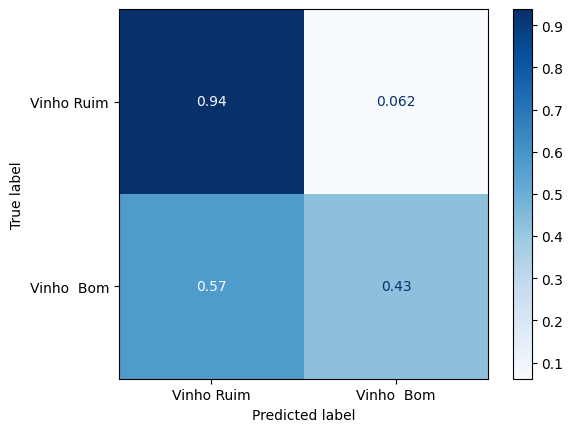

In [17]:
#Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model_xgb, x_test, y_test, cmap='Blues', normalize='true', display_labels=['Vinho Ruim', 'Vinho  Bom'])

A Matriz de confusão indicou que em 57% das vezes o modelo colocou que os vinhos bons são ruins. Isso é claro sinal que o modelo não está conseguindo identificar a classe minoritária.

### Curvas AUC e ROC

In [18]:
from sklearn.metrics import RocCurveDisplay

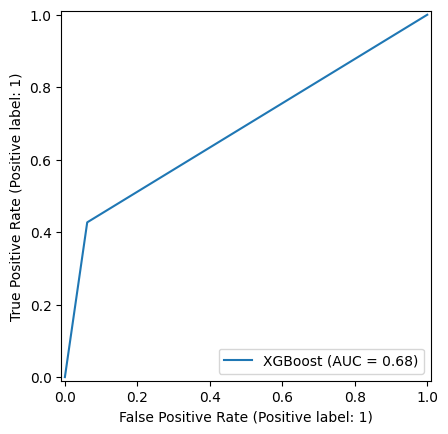

In [19]:
RocCurveDisplay.from_predictions(y_test, y_pred_xgb, name='XGBoost')

Interpretar gráfico

### Validação Cruzada (Com EarlyStop)

In [20]:
dmatrix = xgb.DMatrix(data=x_train, label=y_train) #Conversão do DF em DMatrix

params = {'objective': 'binary:logistic', 'colsample_bytree': 0.3, 'learning_rate':0.1, 'max_depth':5} #Parametros para validação cruzada
#Leaning Rate
#Max_depth
#colsample_bytree
#https://xgboost.readthedocs.io/en/stable/parameter.html

In [21]:
cv = xgb.cv(dtrain=dmatrix, params=params, nfold=3, num_boost_round=100, metrics='error', as_pandas=True, seed=SEED, early_stopping_rounds=5) #early_stopping_rounds

print(cv)

acuracia = (1 - cv['test-error-mean']).iloc[-1]

print(f'Acurácia: {acuracia:.2f}')

   train-error-mean  train-error-std  test-error-mean  test-error-std
0           0.13443         0.010162          0.13444        0.020229
Acurácia: 0.87


# Melhorando o Modelo

### Possiveis melhorias

- Base com os dados balanceados. Uma informação sobre os tipos de balanceamentos: 

https://sigmoidal.ai/estrategias-de-balanceamento-de-dados-em-machine-learning/

https://medium.com/@mate.voros1998/handling-imbalanced-datasets-with-xgboost-optimizing-model-performance-with-smart-parameter-tuning-18568c7783cf

- Hiperparametros: Random Search ou Grid Search para buscar os melhores valores para o modelo.

- Validação cruzada


### Ajustando o Threshold 

In [22]:
import numpy as np

In [ ]:
probab = model_xgb.predict_proba(x_test)[:, 1]

new_threshold = 0.30

custom_pred = (probab >= new_threshold).astype(int)

In [ ]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, custom_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       617
           1       0.49      0.51      0.50        96

    accuracy                           0.86       713
   macro avg       0.70      0.71      0.71       713
weighted avg       0.86      0.86      0.86       713



### Scale Pos Weight

In [32]:
proporcao_classes = (y_train == 0).sum() / (y_train == 1).sum()

# Instanciar o modelo passando o peso calculado
model_xgb_spw = xgb.XGBClassifier(
    scale_pos_weight=proporcao_classes,
    random_state=SEED
)

# Treinar normalmente
model_xgb_spw.fit(x_train, y_train)

y_pred_xgb_spw = model_xgb_spw.predict(x_test)

report = classification_report(y_test, y_pred_xgb_spw)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       617
           1       0.48      0.48      0.48        96

    accuracy                           0.86       713
   macro avg       0.70      0.70      0.70       713
weighted avg       0.86      0.86      0.86       713



### Balanceamento (SMOTE)

In [33]:
from imblearn.over_sampling import SMOTE

In [34]:
smote = SMOTE(random_state=SEED)

x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [36]:
print(f"Vinhos ruins antes: {(y_train == 0).sum()} | Vinhos bons antes: {(y_train == 1).sum()}")
print(f"Vinhos ruins depois: {(y_train_resampled == 0).sum()} | Vinhos bons depois: {(y_train_resampled == 1).sum()}")

Vinhos ruins antes: 264 | Vinhos bons antes: 41
Vinhos ruins depois: 264 | Vinhos bons depois: 264


In [37]:

proporcao_classes = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()

model_xgb_balanced = xgb.XGBClassifier(
    scale_pos_weight=proporcao_classes,
    random_state=SEED
)

# Treinar normalmente
model_xgb_balanced.fit(x_train_resampled, y_train_resampled)

y_pred_xgb_balanced = model_xgb_balanced.predict(x_test)

report = classification_report(y_test, y_pred_xgb_balanced)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       617
           1       0.39      0.52      0.45        96

    accuracy                           0.83       713
   macro avg       0.66      0.70      0.67       713
weighted avg       0.85      0.83      0.84       713



### Espaço de busca do modelo

In [39]:
from sklearn.model_selection import RandomizedSearchCV

In [38]:
params = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [41]:
xgb_search = xgb.XGBClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=params,
    n_iter=20,          # Quantidade de combinações que ele vai sortear e testar
    scoring='f1',       # A métrica que ele deve tentar maximizar (ajuda a classe minoritária)
    cv=3,               # Cross-validation (divide o treino em 3 partes para validar internamente)
    verbose=1,
    random_state=SEED,
    n_jobs=-1           # Usa todos os núcleos do seu processador para ir mais rápido
)

random_search.fit(x_train_resampled, y_train_resampled)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [42]:
print("Melhores parâmetros encontrados:")
print(random_search.best_params_)

Melhores parâmetros encontrados:
{'subsample': 0.6, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [43]:

best_xgb = random_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(x_test)

In [45]:
print("\nRelatório do Novo Modelo:")
print(classification_report(y_test, y_pred_best_xgb))


Relatório do Novo Modelo:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       617
           1       0.44      0.57      0.50        96

    accuracy                           0.85       713
   macro avg       0.69      0.73      0.70       713
weighted avg       0.86      0.85      0.85       713



### Baixando o Threshold do modelo final

In [46]:
probab_best_xgb = best_xgb.predict_proba(x_test)[:, 1]

new_threshold = 0.35

custom_pred = (probab_best_xgb >= new_threshold).astype(int)

In [48]:
from sklearn.metrics import confusion_matrix

print(f"--- Resultados com Threshold de {new_threshold} ---")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, custom_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, custom_pred))

--- Resultados com Threshold de 0.35 ---

Matriz de Confusão:
[[536  81]
 [ 37  59]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       617
           1       0.42      0.61      0.50        96

    accuracy                           0.83       713
   macro avg       0.68      0.74      0.70       713
weighted avg       0.87      0.83      0.85       713



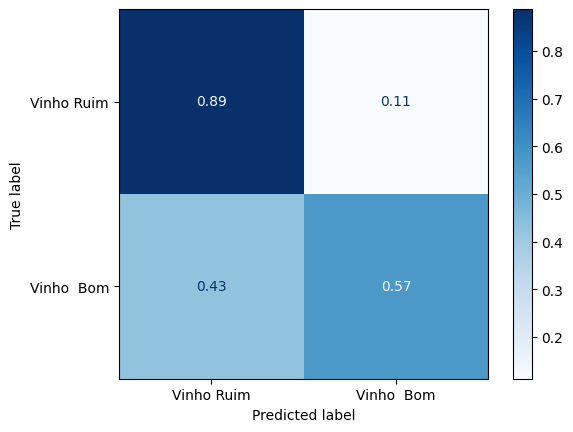

In [50]:
ConfusionMatrixDisplay.from_estimator(best_xgb, x_test, y_test, cmap='Blues', normalize='true', display_labels=['Vinho Ruim', 'Vinho  Bom'])

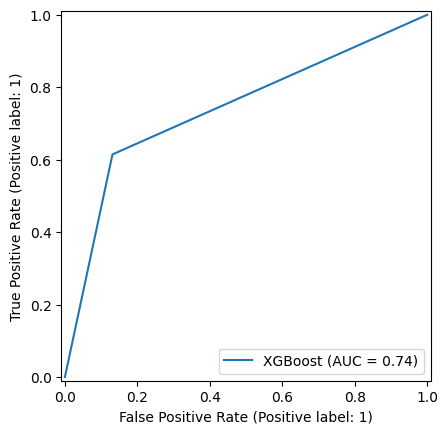

In [49]:
RocCurveDisplay.from_predictions(y_test, custom_pred, name='XGBoost')

## 📝 Conclusões Finais

### Resultados do Modelo Definitivo

| Métrica | Valor Obtido |
| :--- | :---: |
| Precision (Classe Alta Qualidade) | 0.42 |
| Recall (Classe Alta Qualidade) | 0.61 |
| F1-score (Classe Alta Qualidade) | 0.50 |
| AUC-ROC Final | 0.74 |